<a href="https://colab.research.google.com/github/PradipBanik/Build_2026/blob/main/Experimenting_sound.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from scipy.io import wavfile



In [2]:
from google.colab import files

uploaded = files.upload()

Saving apple.wav to apple.wav


In [ ]:
# Load the file directly into a NumPy array
sample_rate, audio_data = wavfile.read("Untitled.wav")

print(f"Sample Rate: {sample_rate} Hz")
print(f"Data Shape: {audio_data.shape}")
print(f"Raw Array Sample Values:\n{audio_data[:20]}") # Inspect first 20 raw readings

Sample Rate: 44100 Hz
Data Shape: (503194,)
Raw Array Sample Values:
[-8354 -8287 -8316 -8304 -8322 -8307 -8237 -8308 -8242 -8370 -8302 -8384
 -8404 -8386 -8311 -8374 -8395 -8330 -8404 -8318]


In [ ]:
!apt-get -qq install -y sounddevice

E: Unable to locate package sounddevice


In [ ]:
import sounddevice as sd
from scipy.io import wavfile



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libasound2-dev libjack-dev libjack0 libportaudio2 libportaudiocpp0
Suggested packages:
  libasound2-doc jackd1 portaudio19-doc
The following packages will be REMOVED:
  libjack-jackd2-0
The following NEW packages will be installed:
  libasound2-dev libjack-dev libjack0 libportaudio2 libportaudiocpp0
  portaudio19-dev
0 upgraded, 6 newly installed, 1 to remove and 1 not upgraded.
Need to get 596 kB of archives.
After this operation, 3,178 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libjack0 amd64 1:0.125.0-3build2 [93.3 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libasound2-dev amd64 1.2.6.1-1ubuntu1.2 [110 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libjack-dev amd64 1:0.125.0-3build2 [206 kB]
Get:4 http://archive.ubuntu.com/ubuntu jamm

In [ ]:
# 1. Load the raw array from your recorded file
sample_rate, audio_data = wavfile.read("Untitled.wav")

print("Sending raw numerical array to DAC and speakers...")

# 2. Pass the raw array directly to speaker hardware
sd.play(audio_data, sample_rate)

# 3. Wait until the sound finishes playing before exiting the script
sd.wait()

print("Playback complete!")

Sending raw numerical array to DAC and speakers...


PortAudioError: Error querying device -1

In [9]:
from IPython.display import Audio
from scipy.io import wavfile
import numpy as np
# Force NumPy to print up to 1,000 numbers before truncating
np.set_printoptions(threshold=2000)

# 1. Load the raw array from your recorded WAV file
sample_rate, audio_data = wavfile.read("apple.wav")

print(f"Sample Rate: {sample_rate} Hz")
print(f"Data Shape: {audio_data.shape}")
print(f"Raw Array Sample Values:\n{audio_data[:20]}") # Inspect first 20 raw readings


# 1. Find the highest and lowest numbers across the entire recording
print(f"Max peak in whole file: {audio_data.max()}")
print(f"Min trough in whole file: {audio_data.min()}")

# 2. Grab 20 samples from around 1.0 second in (where the first big spike is)
sample_at_1sec = 44100
print("\n20 samples during the loud burst at t = 1.0s:")
print(audio_data[sample_at_1sec : sample_at_1sec + 20])
print(audio_data)
# 2. Render an in-browser audio player directly from the NumPy array
# Audio(data=audio_data, rate=sample_rate)

Sample Rate: 44100 Hz
Data Shape: (586971,)
Raw Array Sample Values:
[-28 -13   8 -13 -16  -7  -2 -16  -4   8 -17 -15  -2   3 -20 -15 -17 -34
 -26 -22]
Max peak in whole file: 1231
Min trough in whole file: -1255

20 samples during the loud burst at t = 1.0s:
[ 93  89 116  98  89 109  87  89  97  86  84  63  57  81  76  73  63  35
  37  59]
[-28 -13   8 ... -24  -7 -31]


In [10]:
import numpy as np

# Disable NumPy truncation completely
np.set_printoptions(threshold=np.inf)

# Now this will print every single element in the array
print(audio_data)

[  -28   -13     8   -13   -16    -7    -2   -16    -4     8   -17   -15
    -2     3   -20   -15   -17   -34   -26   -22   -16   -27    18    16
    39    27    39    46    14    44    48    47    62    68    57    32
    39    46     2    -1   -12   -19   -29   -10    -9   -27   -23   -13
   -33   -37   -33   -49   -58   -33   -50   -44   -42   -24   -30   -39
   -19   -30   -32   -49   -41   -58   -66   -36   -53   -45   -30   -11
   -40   -53   -34   -41   -37   -13   -24   -16   -31   -13    -6     6
    28    42    15    25    33    38    58    72    78    83    76    70
    48    37    47    34    30    25    15    -8   -12   -14   -10   -16
   -26     1     0   -23   -16   -11   -22     1   -19   -42   -60   -38
   -24   -45   -45   -12   -16   -51   -27   -45   -30   -22   -24   -23
   -50   -29   -24   -24   -17   -29   -26   -15   -37   -43   -29   -35
   -48   -41   -36   -28   -54   -22   -14     4    18    -7     2    23
    43    74    73    71    92    91    82    78   

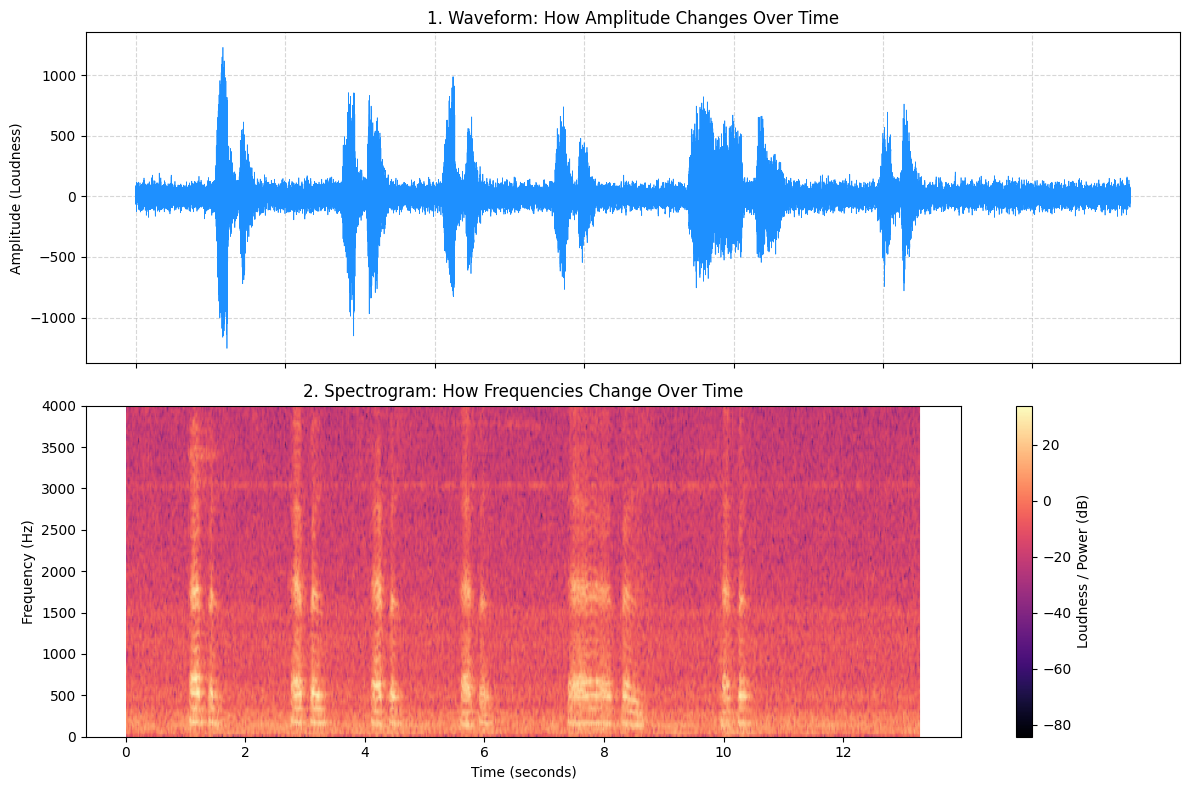

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal

# 1. Load your recorded WAV file
sample_rate, audio_data = wavfile.read("apple.wav")

# If stereo, convert to mono by averaging channels
if len(audio_data.shape) > 1:
    audio_data = audio_data.mean(axis=1)

# Calculate duration in seconds
duration = len(audio_data) / sample_rate
time_axis = np.linspace(0, duration, len(audio_data))

# 2. Create the plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- PLOT 1: Waveform (Amplitude vs Time) ---
ax1.plot(time_axis, audio_data, color='dodgerblue', linewidth=0.5)
ax1.set_ylabel("Amplitude (Loudness)")
ax1.set_title("1. Waveform: How Amplitude Changes Over Time")
ax1.grid(True, linestyle='--', alpha=0.5)

# --- PLOT 2: Spectrogram (Frequency vs Time) ---
# Short-Time Fourier Transform (STFT) calculates FFT across tiny sliding time windows
frequencies, times, Sxx = signal.spectrogram(audio_data, fs=sample_rate, nperseg=1024)

# Convert power to dB (logarithmic scale) for better visual contrast
Sxx_db = 10 * np.log10(Sxx + 1e-10)

# Render the color heatmap
mesh = ax2.pcolormesh(times, frequencies, Sxx_db, shading='gouraud', cmap='magma')
ax2.set_ylabel("Frequency (Hz)")
ax2.set_xlabel("Time (seconds)")
ax2.set_title("2. Spectrogram: How Frequencies Change Over Time")

# Limit Y-axis to 0–4,000 Hz (where human vocal frequencies live)
ax2.set_ylim(0, 4000)

# Add color scale legend
fig.colorbar(mesh, ax=ax2, label='Loudness / Power (dB)')

plt.tight_layout()
plt.show()

In [ ]:
# Experiment 1: Play backwards
Audio(data=audio_data[::-1], rate=sample_rate)



In [ ]:
# Experiment 2: Play at double speed (44100 -> 88200 Hz)
Audio(data=audio_data, rate=sample_rate * 2)



In [ ]:
# Experiment 3: Lower volume by 75%
Audio(data=audio_data * 0.25, rate=sample_rate)

In [ ]:
# Experiment 1: Play backwards
#-8354 -8287 -8316 -8304 -8322 -8307 -8237 -8308 -8242 -8370 -8302 -8384
# -8404 -8386 -8311 -8374 -8395 -8330 -8404 -8318]
Audio(data=[-8386, -8311, -8374, -8395, -8330, -8404, -8318], rate=sample_rate)



In [ ]:
import numpy as np
from IPython.display import Audio

sample_rate = 44100
duration = 5.0  # 2 seconds = 88,200 sample numbers

# 1. Generate 88,200 time steps from 0 to 2 seconds
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
print(t)
# 2. Generate a 440 Hz pure sine wave (Note A4)
# Values smoothly oscillate between -1.0 and +1.0
audio_data = np.sin(2 * np.pi * 440 * t)

print(f"Total Samples Generated: {len(audio_data)}")
print(f"First 10 sample values:\n{audio_data[:10]}")

# 3. Play the manually generated array
Audio(data=audio_data, rate=sample_rate)

[0.00000000e+00 2.26757370e-05 4.53514739e-05 ... 4.99993197e+00
 4.99995465e+00 4.99997732e+00]
Total Samples Generated: 220500
First 10 sample values:
[0.         0.06264832 0.12505052 0.18696144 0.24813785 0.3083394
 0.36732959 0.42487667 0.48075454 0.53474369]
